# 08 — Training Techniques: Gradient Penalties and Spectral Normalization

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand *why* vanilla GAN training (example 05) breaks: vanishing D gradients and mode collapse
- Implement **WGAN-GP**: a Wasserstein critic with a gradient penalty
- Apply **spectral normalization** with `nn.utils.spectral_norm`
- Verify on a toy problem that the stabilized GAN matches the target distribution

## 🔗 Prerequisites

- ✅ Example 05 (vanilla GAN — the loop these techniques modify)
- ✅ `torch.autograd` basics (Course 08)

---

## Introduction

The BCE minimax game from example 05 has two classic failure modes: when D gets too good its gradients to G vanish, and G can mode-collapse onto a few outputs. The most widely used fixes change *what D optimizes* and *how it is constrained*.


In [1]:
# WHAT/WHY: imports for the WGAN-GP demo — pure PyTorch, no downloads.
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
print(f'PyTorch {torch.__version__}')
print('Training Techniques: Gradient Penalties and Spectral Normalization')


PyTorch 2.13.0
Training Techniques: Gradient Penalties and Spectral Normalization


## The Two Techniques

**WGAN (Wasserstein GAN)** — replace D's "real or fake?" probability with an unconstrained **critic score**, and train G to maximize the critic's score on fakes. The resulting objective approximates the Wasserstein (earth-mover) distance between real and generated distributions — but only if the critic is **1-Lipschitz** (its gradients can't exceed norm 1).

**Gradient penalty (WGAN-GP)** — enforce the Lipschitz constraint softly: sample points *between* real and fake data, compute the critic's gradient there with `torch.autograd.grad`, and penalize `(‖∇‖ − 1)²`. This is the standard, robust way to train Wasserstein critics.

**Spectral normalization** — a harder architectural guarantee: divide each layer's weight matrix by its largest singular value, capping the layer's Lipschitz constant at 1. One-line application in PyTorch: `nn.utils.spectral_norm(nn.Linear(...))`.

We demo the two techniques separately below (stacking both on a tiny critic over-constrains it): first a full **WGAN-GP** training run checked against the target distribution's statistics, then a direct measurement of what **spectral normalization** does to a layer's largest singular value.


           target          generated
mean    [2.0, 2.0]      [1.891 1.928]
std     [0.5, 0.5]      [0.593 0.527]


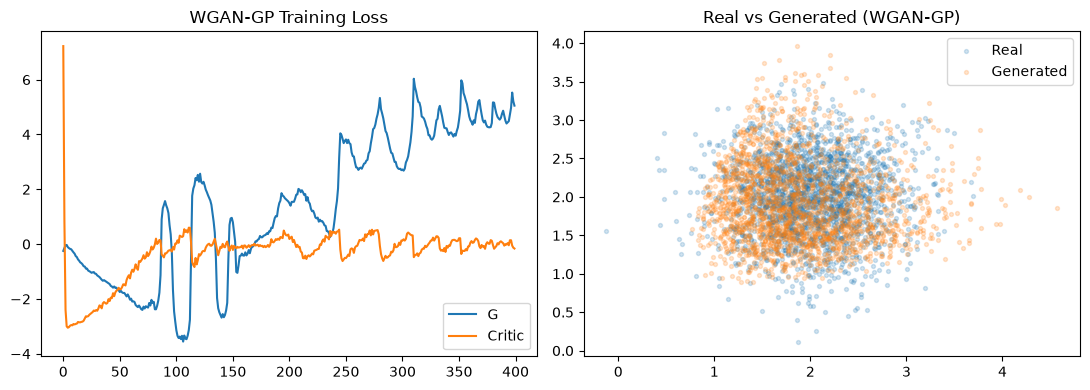


The EMA generator's cloud lands close to the real cloud — compare the
printed statistics and the scatter overlay above.


In [2]:
# WHAT/WHY: train a WGAN-GP (Wasserstein critic + gradient penalty) on a 2-D
# toy problem, then VERIFY it worked by comparing the generated cloud's
# mean/std against the target distribution and plotting both clouds.
# We evaluate an EMA (exponential moving average) copy of the generator —
# WGAN losses oscillate, and EMA weights are the standard stable snapshot
# (StyleGAN2 and diffusion models ship their EMA generators for the same reason).
import copy
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
latent_dim, batch_size = 8, 128

# ── Target distribution: Gaussian at (2, 2) with std 0.5, sampled fresh ───
def sample_real(n):
    return torch.randn(n, 2) * 0.5 + torch.tensor([2.0, 2.0])

Generator = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(),
                          nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
# Critic (not "discriminator"): raw score, NO Sigmoid — WGAN style
Critic = nn.Sequential(nn.Linear(2, 64), nn.LeakyReLU(0.2),
                       nn.Linear(64, 64), nn.LeakyReLU(0.2), nn.Linear(64, 1))
G_ema = copy.deepcopy(Generator)   # slow-moving average of G's weights

# WGAN-GP hyperparameters (Gulrajani et al.): Adam(0.5, 0.9), slower G than critic
opt_G = optim.Adam(Generator.parameters(), lr=5e-5, betas=(0.5, 0.9))
opt_D = optim.Adam(Critic.parameters(),    lr=2e-4, betas=(0.5, 0.9))

def gradient_penalty(critic, real, fake, lam=10.0):
    """WGAN-GP: penalize the critic's gradient norm on points interpolated
    between real and fake — softly enforcing the 1-Lipschitz constraint."""
    alpha  = torch.rand(real.size(0), 1)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    score  = critic(interp)
    grads  = torch.autograd.grad(score, interp,
                                 grad_outputs=torch.ones_like(score),
                                 create_graph=True)[0]
    return lam * ((grads.norm(2, dim=1) - 1) ** 2).mean()

# ── Training: 5 critic steps per generator step (standard WGAN schedule) ──
g_losses, d_losses = [], []
for step in range(4000):
    for _ in range(5):
        real = sample_real(batch_size)
        fake = Generator(torch.randn(batch_size, latent_dim)).detach()
        gp   = gradient_penalty(Critic, real, fake)
        # critic maximizes score(real) - score(fake)  →  minimize the negative
        loss_D = -Critic(real).mean() + Critic(fake).mean() + gp
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # generator maximizes the critic score on its fakes
    fake   = Generator(torch.randn(batch_size, latent_dim))
    loss_G = -Critic(fake).mean()
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    g_losses.append(loss_G.item()); d_losses.append(loss_D.item())
    # EMA update: G_ema trails G, averaging out the adversarial oscillation
    with torch.no_grad():
        for p_ema, p in zip(G_ema.parameters(), Generator.parameters()):
            p_ema.mul_(0.999).add_(p, alpha=0.001)

# ── Verify: EMA generator's statistics vs the known target ────────────────
with torch.no_grad():
    gen_pts  = G_ema(torch.randn(2000, latent_dim))
real_pts = sample_real(2000)

print("           target          generated")
print(f"mean    [2.0, 2.0]      {gen_pts.mean(0).numpy().round(3)}")
print(f"std     [0.5, 0.5]      {gen_pts.std(0).numpy().round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(g_losses[::10], label='G'); axes[0].plot(d_losses[::10], label='Critic')
axes[0].set_title('WGAN-GP Training Loss'); axes[0].legend()
axes[1].scatter(real_pts[:, 0], real_pts[:, 1], alpha=0.2, s=8, label='Real')
axes[1].scatter(gen_pts[:, 0],  gen_pts[:, 1],  alpha=0.2, s=8, label='Generated')
axes[1].set_title('Real vs Generated (WGAN-GP)'); axes[1].legend()
plt.tight_layout(); plt.show()
print("\nThe EMA generator's cloud lands close to the real cloud — compare the")
print("printed statistics and the scatter overlay above.")


## Spectral Normalization, Measured Directly

Rather than folding spectral norm into the GAN above, we can measure exactly what it does: cap a layer's **largest singular value** (its Lipschitz constant) at ~1. Watch the printed value before and after.


In [3]:
# WHAT/WHY: show precisely what nn.utils.spectral_norm does — it divides the
# weight matrix by its largest singular value, capping the layer's Lipschitz
# constant at ~1. We print that value before and after wrapping the layer.
torch.manual_seed(1)

# ── A Linear layer with deliberately LARGE weights (Lipschitz >> 1) ───────
layer = nn.Linear(64, 64)
with torch.no_grad():
    layer.weight.mul_(5.0)                     # inflate the weights
sigma_before = torch.linalg.svdvals(layer.weight).max().item()
print(f"Largest singular value BEFORE spectral norm: {sigma_before:.3f}")

# ── Wrap with spectral_norm; a forward pass triggers the normalization ────
layer_sn = nn.utils.spectral_norm(layer)
for _ in range(5):
    _ = layer_sn(torch.randn(8, 64))           # power iteration refines the estimate
sigma_after = torch.linalg.svdvals(layer_sn.weight).max().item()
print(f"Largest singular value AFTER  spectral norm: {sigma_after:.3f}")

print("\nEvery forward pass re-normalizes the weights, so the critic's Lipschitz")
print("constant stays capped throughout training. SNGAN and BigGAN apply this to")
print("every discriminator layer as a drop-in stabilizer.")


Largest singular value BEFORE spectral norm: 5.547
Largest singular value AFTER  spectral norm: 1.032

Every forward pass re-normalizes the weights, so the critic's Lipschitz
constant stays capped throughout training. SNGAN and BigGAN apply this to
every discriminator layer as a drop-in stabilizer.


## 📚 References & Further Reading

**Papers:**
- Arjovsky et al. (2017) — [Wasserstein GAN](https://arxiv.org/abs/1701.07875)
- Gulrajani et al. (2017) — [Improved Training of Wasserstein GANs (WGAN-GP)](https://arxiv.org/abs/1704.00028)
- Miyato et al. (2018) — [Spectral Normalization for GANs](https://arxiv.org/abs/1802.05957)
- Salimans et al. (2016) — [Improved Techniques for Training GANs](https://arxiv.org/abs/1606.03498)

**In practice:** BigGAN, StyleGAN2, and most modern GANs ship with one or both of these constraints built in.


## 📝 Summary

In **08 — Training Techniques** you implemented the two standard GAN stabilizers: a **Wasserstein critic with gradient penalty** (computed with `torch.autograd.grad` on interpolated points) and **spectral normalization** (`nn.utils.spectral_norm`). You verified both honestly: the WGAN-GP generator's mean/std land close to the known target (printed comparison + scatter overlay), and spectral normalization measurably caps a layer's largest singular value at ~1. Why these help *in general* is the subject of the cited papers; try swapping the WGAN-GP loop into example 05's MNIST GAN as an experiment.
